In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,recall_score,ConfusionMatrixDisplay
import spacy
from wordcloud import WordCloud

In [42]:
df=pd.read_csv("/home/vivekananda-reddy/Desktop/Python/ML Project/data.csv")
df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
117289,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,828.0,4.0,4950.0,40.0,10.0,40.0,baby,17602.0,tupa,SP
117290,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2,8290.0,sao paulo,SP
117291,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories,37175.0,ilicinea,MG
117292,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories,37175.0,ilicinea,MG
117293,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00,60350aa974b26ff12caad89e55993bd6,83750,...,569.0,1.0,150.0,16.0,7.0,15.0,health_beauty,14407.0,franca,SP


In [43]:
#creating separate dataset
nlp_df = df[['review_comment_message','review_score']].copy()
nlp_df.head()

,review_comment_message,review_score
0,"Não testei o produto ainda, mas ele veio corre...",4.0
1,"Não testei o produto ainda, mas ele veio corre...",4.0
2,"Não testei o produto ainda, mas ele veio corre...",4.0
3,Muito bom o produto.,4.0
4,NaN,5.0


In [44]:
nlp_df.isnull().sum()

review_comment_message    67637
review_score                  0
dtype: int64

In [45]:
#removing null rows
nlp_df = nlp_df.dropna(subset=['review_comment_message'])
nlp_df.isnull().sum()

review_comment_message    0
review_score              0
dtype: int64

In [46]:
nlp_df.shape

(49657, 2)

In [47]:

#Lowecasing,removing punctuations,removing stop words and tokenization
stop_words = set(stopwords.words('portuguese'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens
#tokens
nlp_df['tokens'] = nlp_df['review_comment_message'].apply(clean_text)
#converting tokens back to text
nlp_df['clean_text'] = nlp_df['tokens'].apply(lambda x: " ".join(x))

In [ ]:
#setting up output label
nlp_df['sentiment'] = nlp_df['review_score'].apply(
    lambda x: 1 if x >= 4 else 0
)

In [49]:
#vectorization

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(nlp_df['clean_text'])
y = nlp_df['sentiment']


In [ ]:
#sentiment analysis
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [51]:
#finding accuracy and f1 score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8976037051953283
F1 Score: 0.9172969016833374


In [52]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3275  514]
 [ 503 5640]]


Text(0.5, 1.0, 'Confusion Matrix')

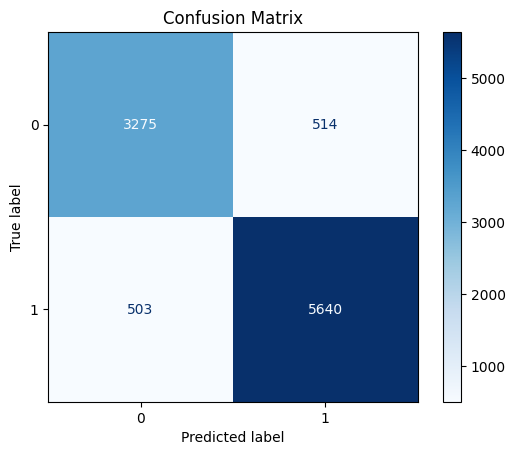

In [61]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")

In [53]:
#finding recall
recall = recall_score(y_test, y_pred)
recall

0.9181181832980628

Text(0.5, 1.0, 'Top 20 Important Words')

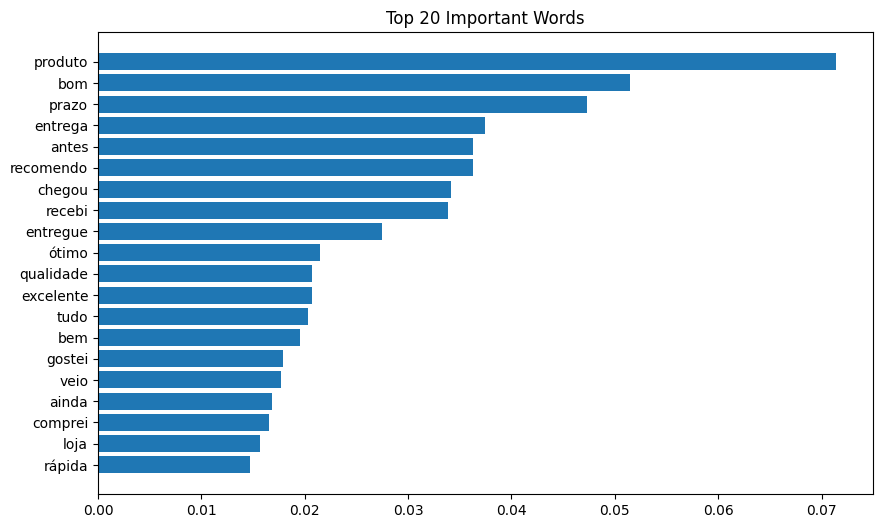

In [54]:
#Top 20 imp words
feature_names = tfidf.get_feature_names_out()
tfidf_scores = np.mean(X_tfidf.toarray(), axis=0)

top_indices = tfidf_scores.argsort()[-20:]
top_words = feature_names[top_indices]
top_scores = tfidf_scores[top_indices]

plt.figure(figsize=(10,6))
plt.barh(top_words, top_scores)
plt.title("Top 20 Important Words")


In [55]:
#checking text is positive or not
positive_text = " ".join(nlp_df[nlp_df['sentiment']==1]['clean_text'])
print(len(positive_text))
print(positive_text[:200])

1295395
testei produto ainda veio correto boas condições apenas caixa veio bem amassada danificada ficará chato pois trata presente testei produto ainda veio correto boas condições apenas caixa veio bem amass


In [56]:
print(nlp_df[nlp_df['sentiment']==1]['clean_text'].apply(type).unique())

[<class 'str'>]


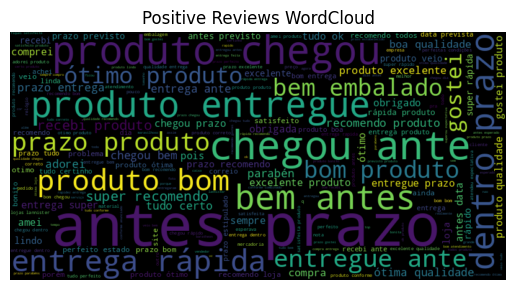

In [57]:
#printing positive text wordcloud
positive_text = " ".join(nlp_df[nlp_df['sentiment']==1]['clean_text'])

wc = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

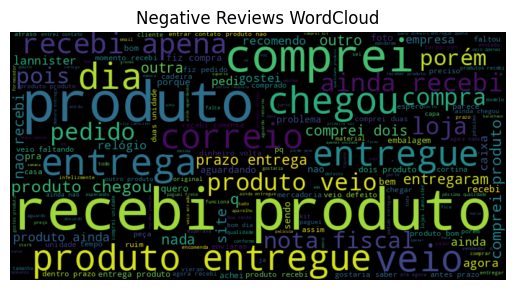

In [58]:
#printing positive text wordcloud
negative_text = " ".join(nlp_df[nlp_df['sentiment']==0]['clean_text'])

wc = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

In [59]:
#Named entity recognization
nlp = spacy.load("xx_ent_wiki_sm")
entities = []

for idx, comment in enumerate(nlp_df['review_comment_message']):
    doc = nlp(comment)
    for ent in doc.ents:
        entities.append({
            "review_index": idx,
            "entity_text": ent.text,
            "entity_label": ent.label_
        })

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(entities)
print(entities_df.head())

   review_index                                        entity_text  \
0             5                                             fiquei   
1             8                                             Gostei   
2            12                                             Demora   
3            13  Protetor De Colchão Para Berço - Algodão Imper...   
4            14  Protetor De Colchão Para Berço - Algodão Imper...   

  entity_label  
0          PER  
1          PER  
2          PER  
3         MISC  
4         MISC  
